In [3]:
import os
import glob
import numpy as np
from itertools import combinations
import pandas as pd

# --- CONFIGURATION ---
# Path to your PM peak annotation folder
# DATASET_PATH = '/media/holidayj/Documents/Data/Platform/final_dataset/Euljiro/0_1_Original_dataset_Eljiro_peak/Euljiro_inner_20221101_f1700_t2000_120_interval_till_1830/val'
# DATASET_PATH = '/media/holidayj/Documents/Data/Platform/final_dataset/Euljiro/0_1_Original_dataset_Eljiro_peak/Euljiro_inner_20221101_f1700_t2000_120_interval_till_1830/train'
# DATASET_PATH = '/media/holidayj/Documents/Data/Platform/final_dataset/Euljiro/0_1_Original_dataset_Eljiro_peak/Euljiro_inner_20221101_f1700_t2000_120_interval_till_1830/test'
# DATASET_PATH = '/media/holidayj/Documents/Data/Platform/final_dataset/Euljiro/0_1_Original_dataset_Eljiro_peak/Euljiro_inner_20221101_f1700_t2000_120_interval_till_1830/val'


# DATASET_PATH = '/media/holidayj/Documents/Data/Platform/final_dataset/Euljiro/0_1_Original_dataset_Eljiro_peak/Euljiro_inner_20251111_f0700_t1000_120_frames_interval/test'
# DATASET_PATH = '/media/holidayj/Documents/Data/Platform/final_dataset/Euljiro/0_1_Original_dataset_Eljiro_peak/Euljiro_inner_20251111_f0700_t1000_120_frames_interval/train'
# DATASET_PATH = '/media/holidayj/Documents/Data/Platform/final_dataset/Euljiro/0_1_Original_dataset_Eljiro_peak/Euljiro_inner_20251111_f0700_t1000_120_frames_interval/val'

# DATASET_PATH = '/media/holidayj/Documents/Data/Platform/final_dataset/Euljiro/0_3_Original_dataset_Euljiro_peak_n_offpeak_combined/test_all_together'
DATASET_PATH = '/media/holidayj/Documents/Data/Platform/final_dataset/Euljiro/0_2_Original_dataset_Euljiro_off_peak_inner_20201128_f1038_t1519/3_class/all'

def yolo_to_bbox(x_c, y_c, w, h):
    """
    Converts YOLO normalized format to (x1, y1, x2, y2).
    Since we only need IoU, absolute pixel values aren't strictly necessary 
    if we stay consistent, but normalized [0-1] works fine for IoU.
    """
    x1 = x_c - w / 2
    y1 = y_c - h / 2
    x2 = x_c + w / 2
    y2 = y_c + h / 2
    return [x1, y1, x2, y2]

def calculate_iou(box1, box2):
    """
    Calculates Intersection over Union (IoU) between two boxes.
    Boxes are [x1, y1, x2, y2].
    """
    x1_inter = max(box1[0], box2[0])
    y1_inter = max(box1[1], box2[1])
    x2_inter = min(box1[2], box2[2])
    y2_inter = min(box1[3], box2[3])

    # Calculate area of intersection
    inter_width = max(0, x2_inter - x1_inter)
    inter_height = max(0, y2_inter - y1_inter)
    inter_area = inter_width * inter_height

    # Calculate area of both boxes
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])

    union_area = area1 + area2 - inter_area
    
    if union_area == 0:
        return 0
    
    return inter_area / union_area

def process_folder(folder_path):
    # List to store results
    data = []
    
    # Get all txt files
    txt_files = glob.glob(os.path.join(folder_path, "*.txt"))
    print(f"Found {len(txt_files)} files in {folder_path}")

    for file_path in txt_files:
        filename = os.path.basename(file_path)
        boxes = []
        
        with open(file_path, 'r') as f:
            lines = f.readlines()
            
            # 1. DENSITY PROXY: Simply the number of lines (objects)
            person_count = len(lines)
            
            for line in lines:
                parts = list(map(float, line.strip().split()))
                # Format: class x_c y_c w h
                # We ignore class (parts[0]) for IoU calculation
                bbox = yolo_to_bbox(parts[1], parts[2], parts[3], parts[4])
                boxes.append(bbox)

        # 2. OCCLUSION PROXY: Mean Inter-box IoU
        iou_values = []
        if person_count < 2:
            mean_iou = 0.0
        else:
            # Generate all possible pairs of boxes in the frame
            for box_a, box_b in combinations(boxes, 2): # it considers each pair "only once" - checked 20260131.
                iou = calculate_iou(box_a, box_b)
                iou_values.append(iou)
            
            mean_iou = np.mean(iou_values) if iou_values else 0.0

        data.append({
            "filename": filename,
            "density_count": person_count,
            "mean_iou": mean_iou
        })

    return pd.DataFrame(data)

# --- EXECUTION ---
if __name__ == "__main__":
    df = process_folder(DATASET_PATH)
    
    # Save to CSV for analysis
    output_csv = "stratification_metrics.csv"
    df.to_csv(output_csv, index=False)
    
    print("-" * 30)
    print(f"Processing Complete. Saved to {output_csv}")
    print("-" * 30)
    print("Quick Stats:")
    print(df[['density_count', 'mean_iou']].describe())
    
    # Optional: Suggest bins based on quartiles
    print("\nSuggested Density Bins (based on quartiles):")
    print(pd.qcut(df['density_count'], q=3, duplicates='drop').value_counts().sort_index())

Found 5936 files in /media/holidayj/Documents/Data/Platform/final_dataset/Euljiro/0_2_Original_dataset_Euljiro_off_peak_inner_20201128_f1038_t1519/3_class/all
------------------------------
Processing Complete. Saved to stratification_metrics.csv
------------------------------
Quick Stats:
       density_count     mean_iou
count    5936.000000  5936.000000
mean        2.117082     0.024968
std         1.819932     0.061467
min         0.000000     0.000000
25%         1.000000     0.000000
50%         1.000000     0.000000
75%         2.000000     0.028580
max        13.000000     0.819001

Suggested Density Bins (based on quartiles):
density_count
(-0.001, 1.0]    3227
(1.0, 2.0]       1284
(2.0, 13.0]      1425
Name: count, dtype: int64


## Generating stratified test lists

1) Calculates Metrics: It scans your test folder to calculate "Density" (count) and "Occlusion" (mean IoU) for every image.

2) Generates Test Lists: It automatically splits the images into the specific groups we defined (Low/Med/High Density, None/Minor/Major Occlusion) and saves them as .txt files ready for YOLO testing. We can use these txt files to test stratified test sets.

In [1]:
import os
import glob
import numpy as np
import pandas as pd
from itertools import combinations

# ================= CONFIGURATION =================
# Path to your YOLO format labels (.txt) and images
DATASET_PATH = '/media/holidayj/Documents/Data/Platform/final_dataset/Euljiro/0_3_Original_dataset_Euljiro_peak_n_offpeak_combined/test_all_together'

# Output directory where the .txt lists will be saved
OUTPUT_DIR = 'stratified_test_lists'
# =================================================

def yolo_to_bbox(x_c, y_c, w, h):
    """Converts YOLO format to [x1, y1, x2, y2]"""
    x1 = x_c - w / 2
    y1 = y_c - h / 2
    x2 = x_c + w / 2
    y2 = y_c + h / 2
    return [x1, y1, x2, y2]

def calculate_iou(box1, box2):
    """Calculates IoU between two boxes [x1, y1, x2, y2]"""
    x1_inter = max(box1[0], box2[0])
    y1_inter = max(box1[1], box2[1])
    x2_inter = min(box1[2], box2[2])
    y2_inter = min(box1[3], box2[3])

    inter_w = max(0, x2_inter - x1_inter)
    inter_h = max(0, y2_inter - y1_inter)
    inter_area = inter_w * inter_h

    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union_area = area1 + area2 - inter_area
    
    return inter_area / union_area if union_area > 0 else 0

def get_density_bin(count):
    if count <= 2: return "density_low"      # 1-2
    elif count <= 5: return "density_medium" # 3-5
    else: return "density_high"              # 6+

def get_occlusion_bin(iou):
    if iou == 0: return "occlusion_none"          # 0
    elif iou < 0.05: return "occlusion_minor"     # 0 < x < 0.05
    else: return "occlusion_major"                # >= 0.05

def process_dataset():
    txt_files = glob.glob(os.path.join(DATASET_PATH, "*.txt"))
    print(f"Found {len(txt_files)} label files in {DATASET_PATH}")
    
    results = []

    for file_path in txt_files:
        # Get corresponding image path (assuming .jpg)
        # Verify if your dataset uses .jpg, .png, etc.
        img_path = file_path.replace('.txt', '.jpg')
        if not os.path.exists(img_path):
            continue

        boxes = []
        with open(file_path, 'r') as f:
            lines = f.readlines()
            density_count = len(lines)
            
            for line in lines:
                parts = list(map(float, line.strip().split()))
                # parts[0] is class_id, parts[1-4] are coordinates
                boxes.append(yolo_to_bbox(parts[1], parts[2], parts[3], parts[4]))

        # Calculate Mean IoU for this frame
        if density_count < 2:
            mean_iou = 0.0
        else:
            ious = [calculate_iou(b1, b2) for b1, b2 in combinations(boxes, 2)]
            mean_iou = np.mean(ious) if ious else 0.0

        results.append({
            'image_path': img_path,
            'density_bin': get_density_bin(density_count),
            'occlusion_bin': get_occlusion_bin(mean_iou)
        })

    return pd.DataFrame(results)

def save_stratified_lists(df):
    if not os.path.exists(OUTPUT_DIR):
        os.makedirs(OUTPUT_DIR)
        
    # Categories to generate
    categories = [
        'density_low', 'density_medium', 'density_high',
        'occlusion_none', 'occlusion_minor', 'occlusion_major'
    ]
    
    print("\n--- Generating Stratified Test Lists ---")
    for cat in categories:
        # Filter based on column name (density_bin or occlusion_bin)
        if 'density' in cat:
            subset = df[df['density_bin'] == cat]
        else:
            subset = df[df['occlusion_bin'] == cat]
            
        filename = os.path.join(OUTPUT_DIR, f"{cat}.txt")
        
        with open(filename, 'w') as f:
            for path in subset['image_path']:
                f.write(path + '\n')
                
        print(f"[{cat}]: {len(subset)} images saved to {filename}")

if __name__ == "__main__":
    df = process_dataset()
    save_stratified_lists(df)
    print("\nDone! You can now run 'test.py' using these .txt files.")

Found 697 label files in /media/holidayj/Documents/Data/Platform/final_dataset/Euljiro/0_3_Original_dataset_Euljiro_peak_n_offpeak_combined/test_all_together

--- Generating Stratified Test Lists ---
[density_low]: 494 images saved to stratified_test_lists/density_low.txt
[density_medium]: 162 images saved to stratified_test_lists/density_medium.txt
[density_high]: 41 images saved to stratified_test_lists/density_high.txt
[occlusion_none]: 443 images saved to stratified_test_lists/occlusion_none.txt
[occlusion_minor]: 146 images saved to stratified_test_lists/occlusion_minor.txt
[occlusion_major]: 108 images saved to stratified_test_lists/occlusion_major.txt

Done! You can now run 'test.py' using these .txt files.


In [3]:
# Quick snippet to count instances in your new .txt files
import os

for label in ['density_high', 'occlusion_major']:
    count = 0
    with open(f'stratified_test_lists/{label}.txt', 'r') as f:
        img_paths = f.readlines()
    
    for p in img_paths:
        label_file = p.replace('.jpg', '.txt').strip()
        with open(label_file, 'r') as lf:
            count += len(lf.readlines())
            
    print(f"{label}: {len(img_paths)} Images -> {count} Instances")

density_high: 41 Images -> 298 Instances
occlusion_major: 108 Images -> 320 Instances


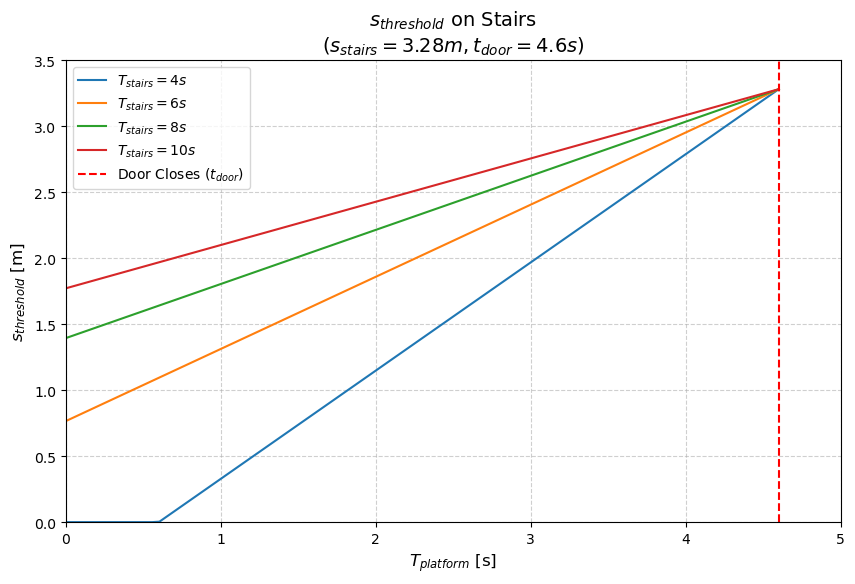

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Constants from user input
s_stairs = 3.28
t_door = 4.6

# Variables for simulation
# T_platform ranges from 0 to t_door (4.6)
T_platform = np.linspace(0, t_door, 100)
T_stairs_values = [4, 6, 8, 10]

plt.figure(figsize=(10, 6))

for T_s in T_stairs_values:
    # Calculate s_threshold using the upper case equation
    s_threshold = s_stairs * (1 - (t_door - T_platform) / T_s)
    
    # Clip values at 0 (distance cannot be negative)
    s_threshold = np.maximum(s_threshold, 0)
    
    plt.plot(T_platform, s_threshold, label=f'$T_{{stairs}} = {T_s}s$')

# Visualize the door closing point
plt.axvline(x=t_door, color='red', linestyle='--', label='Door Closes ($t_{door}$)')

# Graph formatting
plt.title(f'$s_{{threshold}}$ on Stairs\n($s_{{stairs}}=3.28m, t_{{door}}=4.6s$)', fontsize=14)
plt.xlabel('$T_{platform}$ [s]', fontsize=12)
plt.ylabel('$s_{threshold}$ [m]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.ylim(0, 3.5)
plt.xlim(0, 5)

plt.show()